Train a segmentation model using the HAM 10000 kaggle dataset

Using the kaggle API - Need to create a token and store it at 

C:\Users\<Windows-username>\.kaggle\kaggle.json on Windows

Environment variable with KAGGLEHUB_CACHE is also required

In [68]:
import os
import numpy as np

import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
from tqdm import tqdm

import albumentations as A
from albumentations.pytorch import ToTensorV2
from PIL import Image

import matplotlib.pyplot as plt

# import gc
# gc.collect()

# # Empty cached memory
# torch.cuda.empty_cache()



In [69]:
TESTING_IMAGES_PATH = "C:\\Users\\colwy\\Documents\\SFU\Spring2025\\CMPT 419\\Project\\2025_1_project_06\\src\\datasets\\datasets\\kmader\\skin-cancer-mnist-ham10000\\versions\\2\\HAM10000_images_test"
VALIDATION_IMAGES_PATH = "C:\\Users\\colwy\\Documents\\SFU\Spring2025\\CMPT 419\\Project\\2025_1_project_06\\src\\datasets\\datasets\\kmader\\skin-cancer-mnist-ham10000\\versions\\2\\HAM10000_images_validation"
TESTING_MASKS_PATH = "C:\\Users\\colwy\\Documents\\SFU\Spring2025\\CMPT 419\\Project\\2025_1_project_06\\src\\datasets\\datasets\\tschandl\\ham10000-lesion-segmentations\\versions\\1\\HAM10000_segmentations_lesion_tschandl_test"
VALIDATION_MASKS_PATH = "C:\\Users\\colwy\\Documents\\SFU\Spring2025\\CMPT 419\\Project\\2025_1_project_06\\src\\datasets\\datasets\\tschandl\\ham10000-lesion-segmentations\\versions\\1\\HAM10000_segmentations_lesion_tschandl_validation"

lesion_type_dict = {
    'nv': 'Melanocytic nevi',
    'mel': 'Melanoma',
    'bkl': 'Benign keratosis-like lesions ',
    'bcc': 'Basal cell carcinoma',
    'akiec': 'Actinic keratoses',
    'vasc': 'Vascular lesions',
    'df': 'Dermatofibroma'
}

In [70]:
class LesionDataset(Dataset):
    def __init__(
            self, img_dir, mask_dir, transform=None):
        super().__init__()
        self.mask_dir = mask_dir
        self.img_dir = img_dir
        self.images = os.listdir(self.img_dir)
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, index):
        image = self.images[index].replace(".jpg", "")
        img_path = os.path.join(self.img_dir, image + ".jpg")
        mask_path = os.path.join(self.mask_dir, image + "_segmentation.png")
        
        image = np.array(Image.open(img_path).convert("RGB"))
        mask = np.array(Image.open(mask_path).convert("L"), dtype=np.float32)
        mask[mask > 0] = 1.0

        #Apply optional transformations
        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented["image"]
            mask = augmented["mask"].unsqueeze(0)

        return image, mask

Double convolution layers capture more detailed features than a single, larger kernel layer

Methods:
Conv2d 
- Slides a kernel over an image with a certain stride, performing element-wise multiplication

Batch normalization:
- Helps stabilize a network during training. 
- Normalization x-mean / deviation will place all values in a stable range, allowing us to use higher learning rates without causing instability, and it means that no feature on a higher scale will dominate all others
- If one weight is extremely large, the output neuron will become extremely large, and that will cascade throughout the network. Batch norm normalizes the output from activation function, the multiplies it by a arbitrary parameter and adds a arbitrary parameter so as to undo normalization if needed

Order:
- Conv2d with a 3x3 kernel, a stride of 1 and a padding of 1 to maintain size (same convolution), bias is irrelevant with batch normalization
- Batch normalization
- ReLU activation function

Reference: https://www.youtube.com/watch?v=IHq1t7NxS8k

In [71]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, 1, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, 1, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )
    
    def forward(self, x):
        return self.conv(x)

Conv2D introduces zeroes between the elements in order to upsample an image, then overlap the results when outputting a final result
Size is (input - 1) * stride - 2*padding + kernel _ output_padding

We do a kernel size 2 with stride 2 to double the image size
We also multiply the feature by 2 because of concatenating the skip connection

When performing the forward function, keep track of the output of the double convolution for use in each skip connection

The Encoding section:
- X has shape (B, C, H, W) where B is batch size, C is the number of channels (feature maps), H is height and W is width

In [72]:
class UNET(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, features=[64,128,256,512]):
        super(UNET, self).__init__()
        self.upsampling = nn.ModuleList()
        self.downsampling = nn.ModuleList()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        #Downsampling part of UNET
        for feature in features:
            self.downsampling.append(DoubleConv(in_channels, feature))
            in_channels = feature

        #Upsampling part of UNET
        for feature in reversed(features):
            self.upsampling.append(
                nn.ConvTranspose2d(feature*2, feature, kernel_size=2, stride=2)
            )
            self.upsampling.append(DoubleConv(feature*2, feature))
        
        self.bottleneck = DoubleConv(features[-1], features[-1]*2)
        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        skip_connections = []
        for down in self.downsampling:
            x = down(x)
            skip_connections.append(x)
            x = self.pool(x) # Reduce the size of the image

        x = self.bottleneck(x) #The final step between the convolution layer and the dense layer

        #Reverse the skip connections list for use on the encoder side of UNET
        skip_connections = skip_connections[::-1]

        # Iterate through the transconvolution and double conv upsample layers with a step of 2
        for idx in range(0, len(self.upsampling), 2):
            x = self.upsampling[idx](x)
            skip_connection = skip_connections[idx//2]

            if x.shape != skip_connection.shape:
                x = torch.nn.functional.interpolate(x, size=skip_connection.shape[2:], mode="bilinear", align_corners=True)

            concat_skip = torch.concat((skip_connection, x), dim=1) #TODO LEARN
            x = self.upsampling[idx+1](concat_skip)

        return self.final_conv(x)



In [73]:
def testUNET():
    x = torch.randn((3,1,161,161))
    model = UNET(in_channels=1, out_channels=1)
    preds = model(x)

    print(preds.shape)
    print(x.shape)
    assert preds.shape == x.shape

testUNET()

torch.Size([3, 1, 161, 161])
torch.Size([3, 1, 161, 161])


Hyper Parameters

In [74]:
LEARNING_RATE = 1e-4
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 16
NUM_EPOCHS = 50
NUM_WORKERS = 2
IMAGE_HEIGHT = 192
IMAGE_WIDTH = 256
PIN_MEMORY = True
LOAD_MODEL = False

print("Discovered device is:", DEVICE)

Discovered device is: cuda


Util function required in the training process

Get the loaders required for training the segmentation model

In [75]:
def save_checkpoint(state, filename="my_checkpoint.pth.tar"):
    print("-> Saving checkpoint")
    torch.save(state, filename)

def load_checkpoint(checkpoint, model):
    print("-> Loading checkpoint")
    model.load_state_dict(checkpoint["state_dict"])

def validate_fn(loader, model, loss_fn):
    model.eval()
    num_correct = 0
    num_pixels = 0
    dice_score = 0
    total_loss = 0

    with torch.no_grad():
        for data, targets in loader:
            data = data.to(DEVICE)
            targets = targets.float().to(DEVICE)

            preds = model(data)
            loss = loss_fn(preds, targets)
            total_loss += loss.item()

            preds = torch.sigmoid(preds)
            preds = (preds > 0.5).float()

            num_correct += (preds == targets).sum()
            num_pixels += torch.numel(preds)
            dice_score += (2 * (preds * targets).sum()) / (
                (preds + targets).sum() + 1e-8
            )

    accuracy = num_correct / num_pixels * 100
    mean_loss = total_loss / len(loader)
    dice_score /= len(loader)

    print(f"📊 Val Loss: {mean_loss:.4f}, Accuracy: {accuracy:.2f}%, Dice: {dice_score:.4f}")
    model.train()
    return mean_loss, dice_score

In [76]:
def train_model(loader, model, optimizer, loss_fn, scaler, epoch):
    loop = tqdm(loader)
    model.train()
    
    for batch_idx, (data, targets) in enumerate(loop):
        data = data.to(device=DEVICE)
        targets = targets.to(device=DEVICE)

        # Forward
        with torch.cuda.amp.autocast():
            predictions = model(data)
            loss = loss_fn(predictions, targets)

        # Backwards
        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        #Update tqdm loop
        loop.set_description(f"Epoch [{epoch}]")
        loop.set_postfix(loss=loss.item())


In [77]:
def get_training_transformations():
    return A.Compose([
        A.Resize(IMAGE_HEIGHT, IMAGE_WIDTH),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.Rotate(limit=30, p=0.5),
        A.Normalize(mean=(0.0, 0.0, 0.0), std=(1.0, 1.0, 1.0), max_pixel_value=255.0),
        ToTensorV2()
    ])

def get_validation_transformations():
    return A.Compose([
        A.Resize(IMAGE_HEIGHT, IMAGE_WIDTH),
        A.Normalize(mean=(0.0, 0.0, 0.0), std=(1.0, 1.0, 1.0), max_pixel_value=255.0),
        ToTensorV2()
    ])

# Initialize model instance
model = UNET(in_channels=3, out_channels=1)
model = model.to(DEVICE)

loss_fn = nn.BCEWithLogitsLoss() #Binary loss
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

scaler = torch.cuda.amp.GradScaler()

# if LOAD_MODEL:
#     load_checkpoint(torch.load("my_checkpoint.pth.tar"), model, optimizer)

training_data = LesionDataset(
    TESTING_IMAGES_PATH,
    TESTING_MASKS_PATH,
    transform=get_training_transformations(),
)

train_loader = DataLoader(
    training_data,
    batch_size=16,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

validation_data = LesionDataset(
    VALIDATION_IMAGES_PATH,
    VALIDATION_MASKS_PATH,
    transform=get_training_transformations(),
)

validation_loader = DataLoader(
    validation_data,
    batch_size=16,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

C:\Users\colwy\AppData\Local\Temp\ipykernel_15840\1633421931.py:25: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


Test the image loaders by displaying the image, mask and overlay next to each other, ensuring the transforms are applied correctly

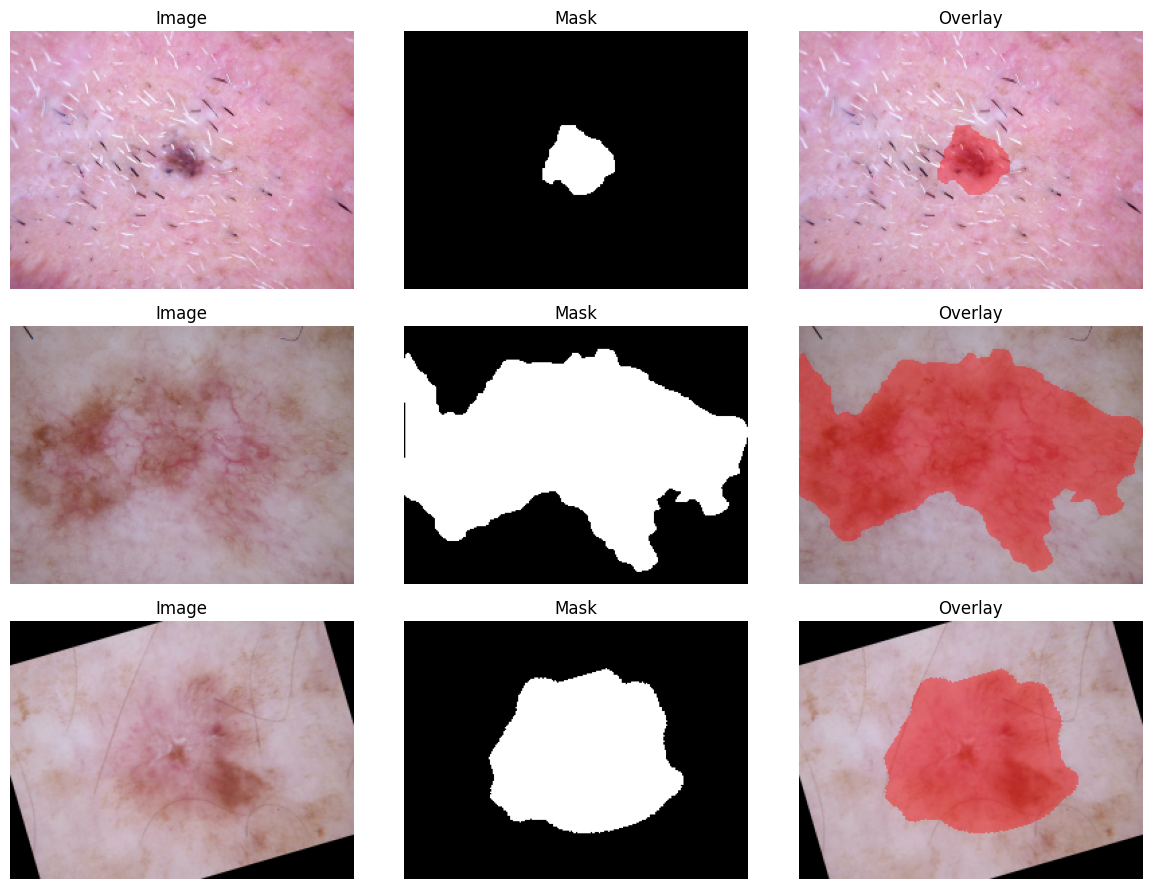

In [78]:
def show_batch_samples(loader, alpha=0.4, num_samples=3):
    model.eval()  # just in case you're doing anything weird in training mode

    images, masks = next(iter(loader))  # grab a batch from the loader
    images = images[:num_samples]
    masks = masks[:num_samples]
    
    fig, axes = plt.subplots(num_samples, 3, figsize=(12, num_samples * 3))
    for i in range(num_samples):
        img = images[i].permute(1, 2, 0).cpu().numpy()  # CHW to HWC
        mask = masks[i].squeeze().cpu().numpy()

        # Ensure pixel values are between 0 and 1
        if img.max() > 1.0:
            img /= 255.0

        # Create red overlay
        red_overlay = np.zeros_like(img)
        red_overlay[..., 0] = 1.0  # Red channel

        # Blend the original image with red overlay where mask is present
        # Makes the image equal to the second array when mask >0.5, and the image when mask is 0
        # Stretches the mask shape to 3 dimensions to apply the alpha
        overlay = np.where(mask[..., None] > 0.5,
                           (1 - alpha) * img + alpha * red_overlay,
                           img)

        axes[i, 0].imshow(img)
        axes[i, 0].set_title("Image")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(mask, cmap='gray')
        axes[i, 1].set_title("Mask")
        axes[i, 1].axis("off")

        axes[i, 2].imshow(overlay)
        axes[i, 2].set_title("Overlay")
        axes[i, 2].axis("off")

    plt.tight_layout()
    plt.show()

show_batch_samples(validation_loader)

Putting it all together, run the training function for the designated number of epochs, and record the mean_losses and dice scores for future graphing, so as to visualize the point of diminishing returns

  0%|          | 0/564 [00:00<?, ?it/s]C:\Users\colwy\AppData\Local\Temp\ipykernel_15840\1711143168.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch [0]: 100%|██████████| 564/564 [06:23<00:00,  1.47it/s, loss=0.422]


📊 Val Loss: 0.1682, Accuracy: 94.56%, Dice: 0.8881


Epoch [1]: 100%|██████████| 564/564 [06:06<00:00,  1.54it/s, loss=0.205] 


📊 Val Loss: 0.1408, Accuracy: 95.00%, Dice: 0.9017


Epoch [2]: 100%|██████████| 564/564 [06:11<00:00,  1.52it/s, loss=0.197] 


...

Epoch [48]: 100%|██████████| 564/564 [05:48<00:00,  1.62it/s, loss=0.0479]


📊 Val Loss: 0.0995, Accuracy: 96.29%, Dice: 0.9282


Epoch [49]: 100%|██████████| 564/564 [05:49<00:00,  1.61it/s, loss=0.059] 


📊 Val Loss: 0.0928, Accuracy: 96.37%, Dice: 0.9289


TypeError: can't convert cuda:0 device type tensor to numpy. Use Tensor.cpu() to copy the tensor to host memory first.

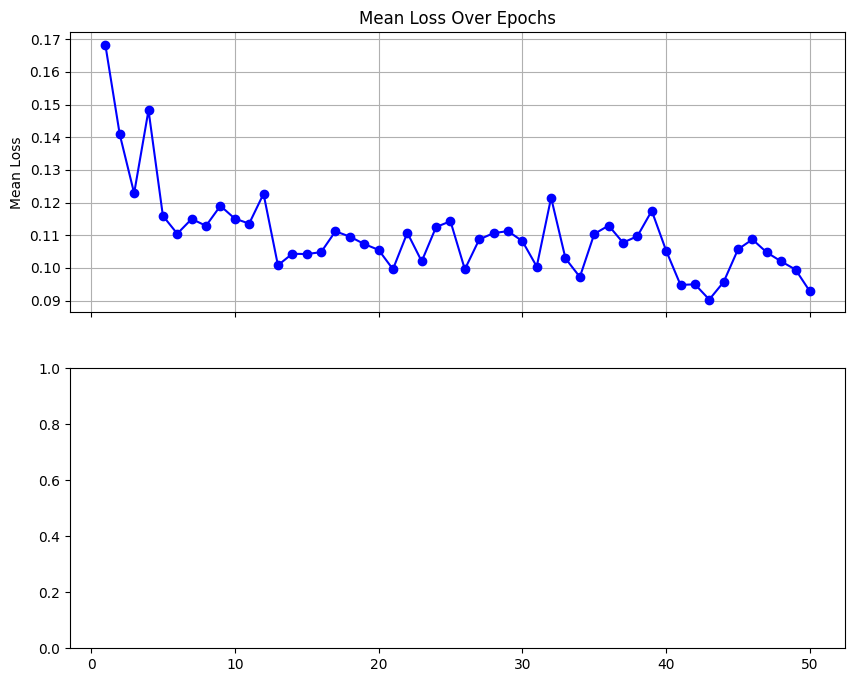

In [79]:
mean_losses = []
dice_scores = []

for epoch in range(NUM_EPOCHS):
    train_model(train_loader, model, optimizer, loss_fn, scaler, epoch)
    mean_loss, dice_score = validate_fn(validation_loader, model, loss_fn)
    mean_losses.append(mean_loss)
    dice_scores.append(dice_score)

torch.save(model.state_dict(), "segmentation_model.pth")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Plot mean loss
ax1.plot(range(1, NUM_EPOCHS + 1), mean_losses, 'b-o')  # blue line with circle markers
ax1.set_title('Mean Loss Over Epochs')
ax1.set_ylabel('Mean Loss')
ax1.grid(True)

# Plot dice score
ax2.plot(range(1, NUM_EPOCHS + 1), dice_scores, 'r-o')  # red line with circle markers
ax2.set_title('Dice Score Over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Dice Score')
ax2.grid(True)

# Adjust layout
plt.tight_layout()
plt.show()